In [5]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import csv
import os

from scipy.integrate import odeint
from matplotlib.ticker import MultipleLocator

from matplotlib.ticker import MaxNLocator

In [3]:
plt.rcParams["font.family"] = "Arial"

### Parameters and initial conditions

In [82]:
N = 100

dt = 0.021
T = round(30 / dt)
t = np.linspace(0, T * dt, T + 1)

R0, W0, V0 = 70, 20, 10
y0 = [R0, W0, V0]

R_s, W_s, V_s = "R", "W", "V"

num_simulations = 200
output_dir = "abm_outputs"
os.makedirs(output_dir, exist_ok=True)

# Base parameters
base_params = {
    "kappa": 3.5,
    "e": 1.1,
    "v_w": 0.8,
    "sigma": 0.01,
    "gamma": 0.03,
    "beta": 0.0
}

# Coefficient of variation
# CV=1 represents exponential distribution, CV<1 moderate skewness, CV>1 heavy skewed 
cv_dict = {
    "kappa": 0.6,
    "e": 0.6,
    "v_w": 0.6,
    "sigma": 0.6,
    "gamma": 0.6,
    "beta": 0.0
}

# Define networks
k1_avg = 4
k2_avg = 14

G1 = nx.erdos_renyi_graph(N, k1_avg / N, seed=1)
G2 = nx.erdos_renyi_graph(N, k2_avg / N, seed=2)

In [83]:
# Draw heterogeneous parameters 
def gamma_draw(mean, cv, size):
    if mean == 0:
        return np.zeros(size)
    shape = 1.0 / (cv**2)
    scale = mean / shape
    return np.random.gamma(shape, scale, size)


def beta_draw(mean, cv, size):
    if mean <= 0:
        return np.zeros(size)
    if mean >= 1:
        return np.ones(size)

    var = (cv * mean)**2
    max_var = mean * (1 - mean)

    if var >= max_var:
        raise ValueError(f"Infeasible CV for Beta: mean={mean}, cv={cv}")

    temp = mean * (1 - mean) / var - 1
    alpha = mean * temp
    beta = (1 - mean) * temp

    return np.random.beta(alpha, beta, size)


def draw_agent_parameters():
    params = {}
    for key in base_params:
        mean = base_params[key]
        cv = cv_dict.get(key, 0.0)
        if key in ["sigma", "gamma"]:
            params[key] = beta_draw(mean, cv, N)
        elif key == "beta" and mean == 0:
            params[key] = np.zeros(N)
        elif key == "beta":
            params[key] = beta_draw(mean, cv, N)
        else:
            params[key] = gamma_draw(mean, cv, N)
    return params

## Mean-field approx.

In [84]:
def model(y, t, kappa, e, v_w, beta, sigma, gamma, k1, k2, H):
    R, W, V = y

    dR = kappa * W - e * R - (k1 * sigma / H) * (R * V) + (k2 * gamma / H) * (V * R) + beta * V
    dW = -kappa * W + e * R - v_w * W + (k1 * sigma / H) * (R * V)
    dV = v_w * W - (k2 * gamma / H) * (R * V) - beta * V

    return [dR, dW, dV]

sol_baseline = odeint(
    model,
    y0,
    t,
    args=(
        base_params["kappa"],
        base_params["e"],
        base_params["v_w"],
        base_params["beta"],
        base_params["sigma"],
        base_params["gamma"],
        k1_avg,
        k2_avg,
        N
    )
)

## Simulations

In [85]:
# Draw parameters

def gamma_draw(mean, cv, size):
    if mean == 0:
        return np.zeros(size)
    if cv == 0:
        return np.full(size, mean)

    shape = 1.0 / (cv ** 2)
    scale = mean / shape
    return np.random.gamma(shape, scale, size)

def beta_draw(mean, cv, size):
    if mean <= 0:
        return np.zeros(size)
    if mean >= 1:
        return np.ones(size)
    if cv == 0:
        return np.full(size, mean)

    var = (cv * mean) ** 2
    max_var = mean * (1 - mean)

    if var >= max_var:
        raise ValueError(f"Infeasible CV for Beta distribution: mean={mean}, cv={cv}")

    temp = mean * (1 - mean) / var - 1
    alpha = mean * temp
    beta = (1 - mean) * temp

    return np.random.beta(alpha, beta, size)


# Draw one heterogeneous parameter set for all N agents
def draw_agent_parameters(N, base_params, cv_dict, seed=None):
    rng_state = None
    if seed is not None:
        rng_state = np.random.get_state()
        np.random.seed(seed)

    params = {}
    for key in base_params:
        mean = base_params[key]
        cv = cv_dict.get(key, 0.0)

        if key in ["sigma", "gamma", "beta"]:
            params[key] = beta_draw(mean, cv, N)
        else:
            params[key] = gamma_draw(mean, cv, N)

    if rng_state is not None:
        np.random.set_state(rng_state)

    return params

In [86]:
# Determine the next state of an individual based on their current state and interactions
def transition(state, neighbors1, neighbors2, pars):
    new_state = state

    e = pars["e"]
    kappa = pars["kappa"]
    v_w = pars["v_w"]
    sigma = pars["sigma"]
    gamma = pars["gamma"]
    beta = pars["beta"]

    if state == R_s:
        vacant_neighbors = sum(n == V_s for n in neighbors1)
        p_exh = 1 - (1 - sigma * dt) ** vacant_neighbors
        if np.random.rand() < p_exh or np.random.rand() < e * dt:
            new_state = W_s

    elif state == W_s:
        if np.random.rand() < kappa * dt:
            new_state = R_s
        elif np.random.rand() < v_w * dt:
            new_state = V_s

    elif state == V_s:
        rooted_neighbors = sum(n == R_s for n in neighbors2)
        p_in = 1 - (1 - gamma * dt) ** rooted_neighbors
        if np.random.rand() < beta * dt or np.random.rand() < p_in:
            new_state = R_s

    return new_state


# Run
def run_abm(agent_params):
    states = np.array([R_s] * R0 + [W_s] * W0 + [V_s] * V0)
    np.random.shuffle(states)

    history = np.zeros((T + 1, 3), dtype=float)
    history[0] = [R0, W0, V0]

    for tt in range(1, T + 1):
        next_states = states.copy()

        for i in range(N):
            neighbors1 = [states[n] for n in G1.neighbors(i)]
            neighbors2 = [states[n] for n in G2.neighbors(i)]

            pars_i = {k: agent_params[k][i] for k in agent_params}
            next_states[i] = transition(states[i], neighbors1, neighbors2, pars_i)

        states = next_states

        history[tt, 0] = np.sum(states == R_s)
        history[tt, 1] = np.sum(states == W_s)
        history[tt, 2] = np.sum(states == V_s)

    # convert to fractions
    history = history / N
    return history


# Draw once the fixed agent parameters
agent_params_fixed = draw_agent_parameters(
    N = N,
    base_params = base_params,
    cv_dict = cv_dict,
    seed = 73
)

### Run Simulations

In [87]:
all_abm = np.zeros((num_simulations, T + 1, 3), dtype=float)

for sim in range(num_simulations):
    all_abm[sim] = run_abm(agent_params_fixed)

# ABM statistics
mean_abm = np.mean(all_abm, axis=0)
std_abm = np.std(all_abm, axis=0)

# MF output in fraction
mf_frac = sol_baseline / N

### Save results

In [88]:
# Save parameters as a dataframe
params_df = pd.DataFrame(agent_params_fixed)
params_df["agent_id"] = np.arange(N)
params_df = params_df[["agent_id"] + list(base_params.keys())]

params_long = params_df.melt(
    id_vars="agent_id",
    var_name="parameter",
    value_name="value"
)
params_long["baseline_value"] = params_long["parameter"].map(base_params)
params_long["cv"] = params_long["parameter"].map(cv_dict)
params_long.to_csv(os.path.join(output_dir, "agent_parameters_long.csv"), index=False)

In [89]:
# Save aggregated results for plotting
states = ["R", "W", "V"]

# ABM aggregated
abm_rows = []
for i, state in enumerate(states):
    for tt in range(T + 1):
        abm_rows.append({
            "time_index": tt,
            "time": t[tt],
            "state": state,
            "model": "ABM",
            "mean": mean_abm[tt, i],
            "std": std_abm[tt, i]
        })

# MF aggregated
mf_rows = []
for i, state in enumerate(states):
    for tt in range(T + 1):
        mf_rows.append({
            "time_index": tt,
            "time": t[tt],
            "state": state,
            "model": "MF_approx",
            "mean": mf_frac[tt, i],
            "std": 0.0
        })
agg = pd.DataFrame(abm_rows + mf_rows)
agg.to_csv(os.path.join(output_dir, "agg_results.csv"), index=False)

In [90]:
# Save all simulation results for the ABM
abm_long_rows = []

for sim in range(num_simulations):
    for tt in range(T + 1):
        for i, state in enumerate(states):
            abm_long_rows.append({
                "simulation": sim,
                "time_index": tt,
                "time": t[tt],
                "state": state,
                "value": all_abm[sim, tt, i]
            })

abm_long = pd.DataFrame(abm_long_rows)
abm_long.to_csv(os.path.join(output_dir, "abm_long_results.csv"), index=False)

### Load data

In [4]:
# Load simmulation agg results
agg = pd.read_csv("C:/Users/ip2347/Desktop/[rev] Simulations_CUSP/abm_outputs_cv0.8_N100_0413/agg_results.csv")

# Load parameter table
params_long = pd.read_csv("C:/Users/ip2347/Desktop/[rev] Simulations_CUSP/abm_outputs_cv0.8_N100_0413/agent_parameters_long.csv")

### Plots

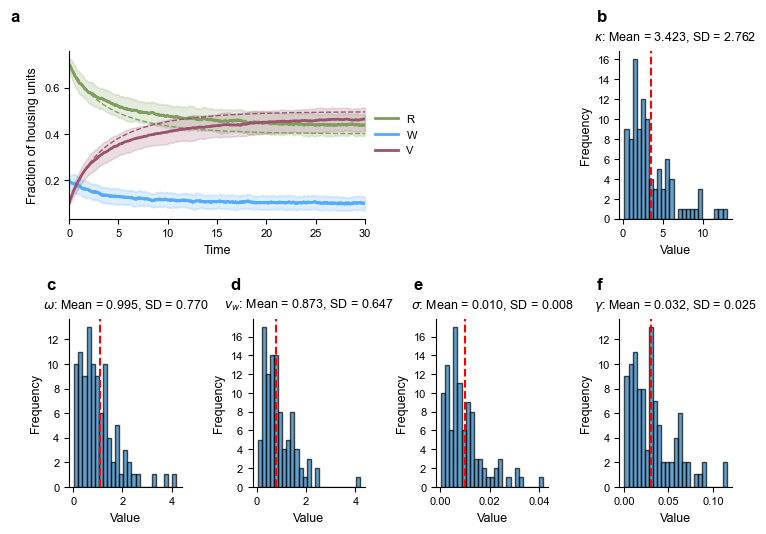

In [6]:
colors = ['#7f9e5d', '#56aaff', '#9b536d']
states = ['R', 'W', 'V']
models = ["ABM", "MF_approx"]

symbol_map = {
    "kappa": r"\kappa",
    "e": r"\omega",
    "v_w": r"v_{w}",
    "sigma": r"\sigma",
    "gamma": r"\gamma",
    "beta": r"\beta"
}

param_names = ["kappa", "e", "v_w", "sigma", "gamma"]


# Plots
fig = plt.figure(figsize=(190/25.4, 140/25.4))
gs = fig.add_gridspec(2, 4)

'''
ax_a = fig.add_subplot(gs[0, 0:2])  # panel a: twice the width
ax_b = fig.add_subplot(gs[0, 2])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
ax_e = fig.add_subplot(gs[1, 2])
ax_f = fig.add_subplot(gs[1, 3])
'''

ax_a = fig.add_subplot(gs[0, 0:2])  # panel a: twice the width
ax_b = fig.add_subplot(gs[0, 3])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
ax_e = fig.add_subplot(gs[1, 2])
ax_f = fig.add_subplot(gs[1, 3])


# Panel a
for i, state in enumerate(states):
    for model_name in models:
        subset = agg[
            (agg["state"] == state) & (agg["model"] == model_name)
        ].sort_values("time")

        time_vals = subset["time"].values
        mean_vals = subset["mean"].values
        std_vals = subset["std"].values

        if model_name == "ABM":
            ax_a.plot(
                time_vals,
                mean_vals,
                color = colors[i],
                linewidth = 2,
                label = f"{state}"
            )
            ax_a.fill_between(
                time_vals,
                mean_vals - std_vals,
                mean_vals + std_vals,
                color = colors[i],
                alpha = 0.2
            )
        else:
            ax_a.plot(
                time_vals,
                mean_vals,
                color = colors[i],
                linestyle="--",
                linewidth = 1
            )

ax_a.set_xlabel("Time", fontsize = 9)
ax_a.set_ylabel("Fraction of housing units", fontsize = 9)
ax_a.set_xlim(0, 30)
#ax_a.legend(ncol=2, fontsize = 8, frameon=False)
ax_a.legend(loc = "center left",
    bbox_to_anchor = (1.02, 0.5),
    fontsize = 8,
    frameon = False,
    borderaxespad = 0.0)
ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)
ax_a.tick_params(axis = "both", labelsize = 8)


# Parameter distributions
hist_axes = [ax_b, ax_c, ax_d, ax_e, ax_f]

for ax, key in zip(hist_axes, param_names):
    subset = params_long[params_long["parameter"] == key]
    values = subset["value"].values
    baseline_val = subset["baseline_value"].iloc[0]
    mean_val = np.mean(values)
    std_val = np.std(values)

    ax.hist(values, bins = 25, alpha = 0.7, edgecolor = "black")
    ax.axvline(baseline_val, color = "red", linestyle = "--", linewidth = 1.5)

    ax.set_title(
        rf"${symbol_map[key]}$: Mean = {mean_val:.3f}, SD = {std_val:.3f}",
        fontsize = 9, pad = 8)
    ax.set_xlabel("Value", fontsize = 9)
    ax.set_ylabel("Frequency", fontsize = 9)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis = "both", labelsize = 8)

# Labels
panel_axes = [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f]
panel_labels = ["a", "b", "c", "d", "e", "f"]

for ax, lab in zip(panel_axes, panel_labels):
    ax.text(
        -0.2, 1.25, lab,
        transform = ax.transAxes,
        fontsize = 12,
        fontweight = "bold",
        fontfamily = "Arial",
        va = "top", 
        ha = "left"
    )


plt.tight_layout()
#plt.savefig("C:/Users/ip2347/Desktop/[rev] Simulations_CUSP/[rev] Simulation_heterogeneous_04_13_N100_CV08.pdf", bbox_inches='tight', dpi = 900) ### CUSP
plt.show()